In [2]:
import numpy as np
import pandas as pd
import ast
from sqlite3 import Time


# 1. Prevent Pandas from wrapping columns into multiple lines
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # Set a wide display threshold
pd.set_option('display.max_rows', None)     # Show all rows

# Load a 50,000-row sample first (full file has ~1M rows)
#df = pd.read_csv('SGJobData.csv', nrows=50000)
df = pd.read_csv('../SGJobData.csv')

print(df.head())
print(df.shape)   # (rows, columns)

# 1. Structural Description: View column names, non-null counts, and data types
print("--- STRUCTURAL INFO ---")
df.info()

# 2. Statistical Description (Numeric columns): View count, mean, min, max, and percentiles
print("\n--- NUMERIC COLUMNS DESCRIBE ---")
print(df.describe())

# 3. Text/Categorical Description (String columns): View count, unique values, top item, and frequency
print("\n--- TEXT/CATEGORICAL COLUMNS DESCRIBE ---")
print(df.describe(include=['object']))


#unique values and their exact counts for each column
for column in df.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df[column].value_counts().head(10))  # Show top 10 unique values
    print("\n" + "-"*40 + "\n")  # Visual separator


'''
#unique values and their exact counts for each column
for column in df.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")  # Visual separator
'''

# Count how many exact duplicate rows exist before dropping
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Find and print the missing value counts for each column
print("=== Missing Values ===")
print(df.isnull().sum())


                                          categories employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies  occupationId    positionLevels                postedCompany_name  salary_maximum  salary_minimum salary_type  status_id status_jobStatus                                              title  average_salary
0  [{"id":13,"category":"Environment / Health"},{...       Permanent          2023-05-08                      False   MCF-2023-0252866              2023-04-08                   2023-03-30                     2                                   5                         151                       0                  1           NaN         Executive               WORKSTONE PTE. LTD.            2800            2000     Monthly          0           Closed  Food Technologist - Cl

In [35]:
# Data cleaning
'''
clean is based on "report/data_dictionary.md" 
'''    
#-----remove duplicates rows, drop unnecessary columns, drop single row with missing values

# Drop duplicates, keep='first' ensures you keep the first occurrence and delete the rest
df = df.drop_duplicates(keep='first')

# Drop columns that are not useful for analysis
columns_to_drop = ['occupationId', 'status_id', 'status_jobStatus', 'salary_type']
df = df.drop(columns=columns_to_drop, axis=1)

# Get row indices where any column has a missing value
missing_rows = df[df.isnull().any(axis=1)].index.tolist()
print("Rows with missing values:")
print(missing_rows)

# Drop the row with missing values (row 197478)
df = df.dropna()

'''
# This part is TBD
# Filter dataframe to keep rows where both salary_minimum and salary_maximum are within specified ranges
sal_min=500
sal_max=250000
df = df.query(f"{sal_min} <= salary_minimum <= {sal_max} and {sal_min} <= salary_maximum <= {sal_max}")
'''

# Convert metadata_expiryDate, metadata_newPostingDate, metadata_originalPostingDate to datetime format
date_cols = [
    "metadata_expiryDate",
    "metadata_newPostingDate",
    "metadata_originalPostingDate",
]
df[date_cols] = df[date_cols].apply(pd.to_datetime)


#-----New Features in Database (15 columns)

# Salary-Related Features
df['salary_median'] = ((df['salary_minimum'] + df['salary_maximum']) / 2).astype(int)
df['salary_range_width'] = (df['salary_maximum'] - df['salary_minimum']).astype(int)
conditions = [
    (df['salary_median'] < 3000),
    (df['salary_median'] >= 3000) & (df['salary_median'] < 6000),
    (df['salary_median'] >= 6000) & (df['salary_median'] < 10000),
    (df['salary_median'] >= 10000) & (df['salary_median'] <= 20000),
    (df['salary_median'] > 20000)
]
categories = ['Entry', 'Mid', 'Senior', 'Lead', 'Executive']
df['salary_band'] = np.select(conditions, categories, default='Unknown')

#Competition & Demand Features
df['applications_per_vacancy'] = df['metadata_totalNumberJobApplication'] / df['numberOfVacancies']
repost_median = df['metadata_repostCount'].median()
apps_per_vac_median = df['applications_per_vacancy'].median()
df['is_hard_to_fill'] = (
    (df['metadata_repostCount'] > repost_median) & 
    (df['applications_per_vacancy'] < apps_per_vac_median)
)
df['is_selective_hire'] = (
    (df['metadata_repostCount'] < repost_median) & 
    (df['applications_per_vacancy'] > apps_per_vac_median)
)

#Industry Features
parsed_series = df['categories'].apply(ast.literal_eval)
df['industry_list'] = [",".join([item['category'] for item in row]) for row in parsed_series]
df['industry_primary'] = [row[0]['category'] for row in parsed_series]

df = df.drop(columns='categories', axis=1)

#add one-hot encoding for industry_list
#df_encoded = df['industry_list'].str.get_dummies(sep=',')
#df = df.join(df_encoded)

#Time-Based Features
df['posting_year'] = df['metadata_originalPostingDate'].dt.year
df['posting_month'] = df['metadata_originalPostingDate'].dt.month
df['posting_quarter'] = df['metadata_originalPostingDate'].dt.quarter
df['posting_weekday'] = df['metadata_originalPostingDate'].dt.weekday
df['days_to_expiry'] = (df['metadata_expiryDate'] - df['metadata_originalPostingDate']).dt.days

#Additional Features
df['is_agency_post'] = df['metadata_isPostedOnBehalf'].astype(bool)
df['posting_month_year'] = df['metadata_originalPostingDate'].dt.strftime('%Y-%m')

print("=== Data Cleaning Complete ===")


Rows with missing values:
[197478]
=== Data Cleaning Complete ===


In [36]:
# re-check the db after cleaning

print(df.head())
print(df.shape)   # (rows, columns)

# 1. Structural Description: View column names, non-null counts, and data types
print("--- STRUCTURAL INFO ---")
df.info()

# 2. Statistical Description (Numeric columns): View count, mean, min, max, and percentiles
print("\n--- NUMERIC COLUMNS DESCRIBE ---")
print(df.describe())

# 3. Text/Categorical Description (String columns): View count, unique values, top item, and frequency
print("\n--- TEXT/CATEGORICAL COLUMNS DESCRIBE ---")
print(df.describe(include=['object']))

'''
#unique values and their exact counts for each column
for column in df.columns:
    print(f"=== Unique Values for Column: {column} ===")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")  # Visual separator
'''

# Count how many exact duplicate rows exist before dropping
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Find and print the missing value counts for each column
print("=== Missing Values ===")
print(df.isnull().sum())

  employmentTypes metadata_expiryDate  metadata_isPostedOnBehalf metadata_jobPostId metadata_newPostingDate metadata_originalPostingDate  metadata_repostCount  metadata_totalNumberJobApplication  metadata_totalNumberOfView  minimumYearsExperience  numberOfVacancies    positionLevels                postedCompany_name  salary_maximum  salary_minimum                                              title  average_salary  salary_median  salary_range_width salary_band  applications_per_vacancy  is_hard_to_fill  is_selective_hire                                      industry_list        industry_primary  posting_year  posting_month  posting_quarter  posting_weekday  days_to_expiry  is_agency_post posting_month_year
0       Permanent          2023-05-08                      False   MCF-2023-0252866              2023-04-08                   2023-03-30                     2                                   5                         151                       0                  1         Executive  

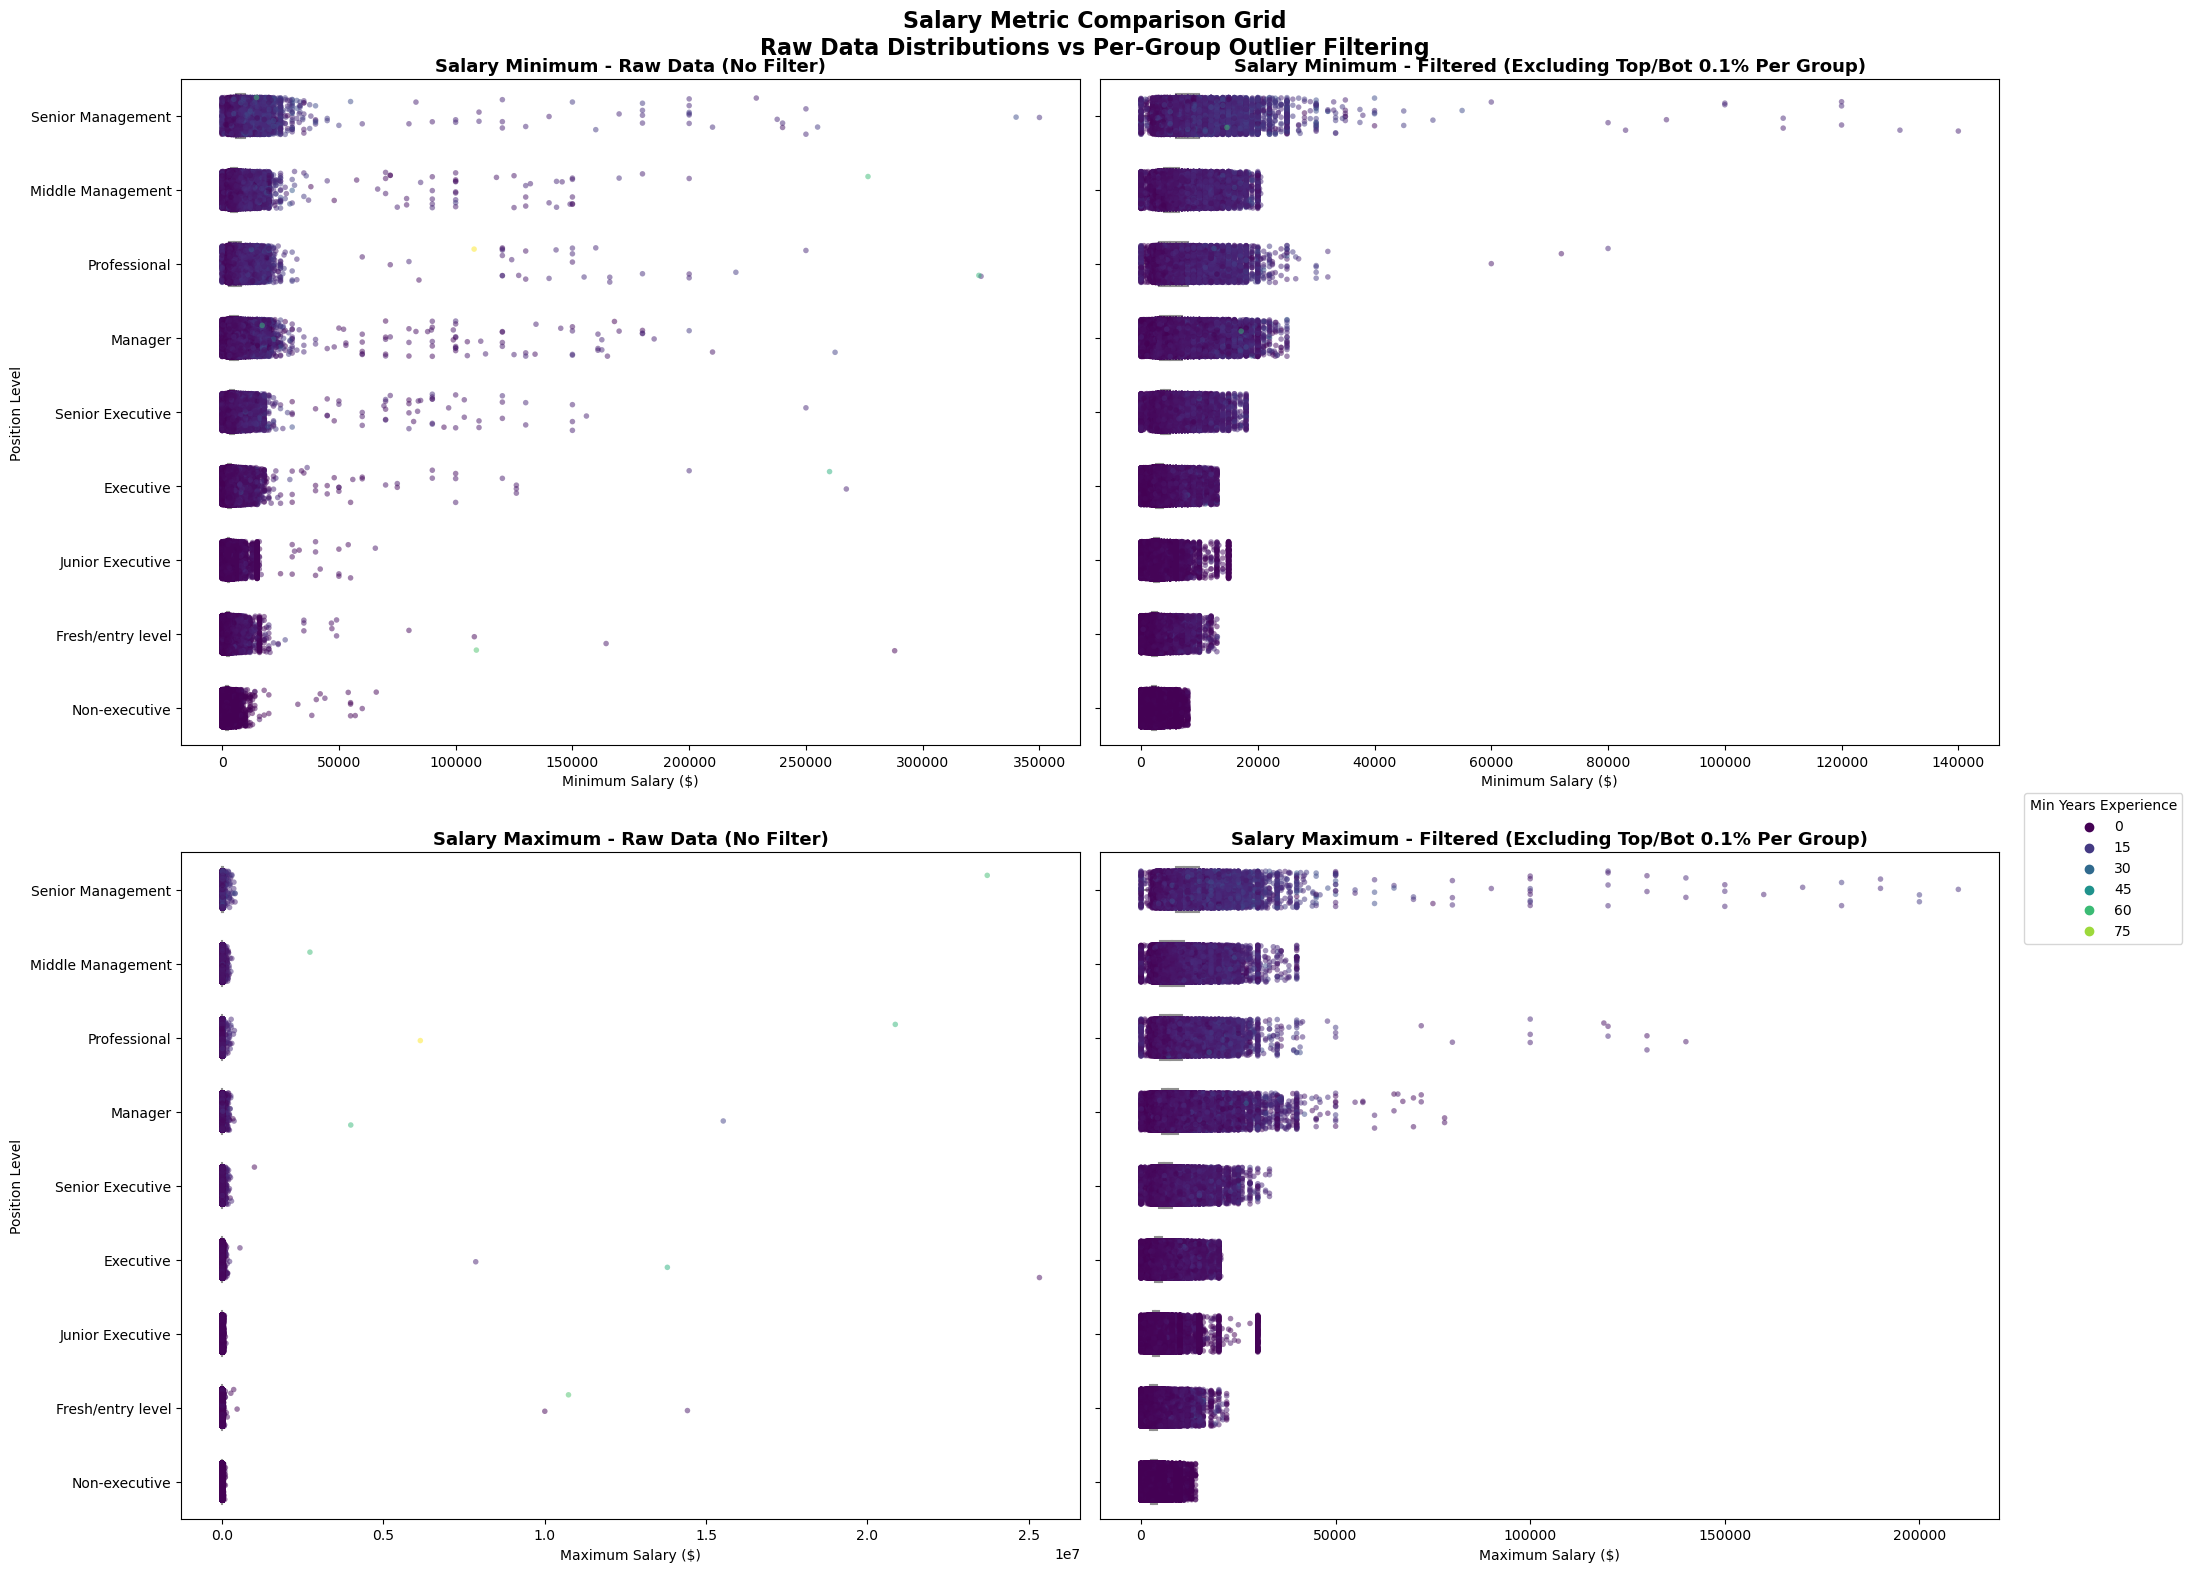

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 1. PREPARE THE DATA & FILTERS (0.1% Top/Bottom per position level group)
# ----------------------------------------------------------------------
# Filters for salary_minimum
min_lower = df.groupby('positionLevels')['salary_minimum'].transform(lambda x: x.quantile(0.001))
min_upper = df.groupby('positionLevels')['salary_minimum'].transform(lambda x: x.quantile(0.999))
df_min_filtered = df[(df['salary_minimum'] >= min_lower) & (df['salary_minimum'] <= min_upper)]

# Filters for salary_maximum
max_lower = df.groupby('positionLevels')['salary_maximum'].transform(lambda x: x.quantile(0.001))
max_upper = df.groupby('positionLevels')['salary_maximum'].transform(lambda x: x.quantile(0.999))
df_max_filtered = df[(df['salary_maximum'] >= max_lower) & (df['salary_maximum'] <= max_upper)]

# Establish standard sorting orders based on group medians
order_min = df.groupby('positionLevels')['salary_minimum'].median().sort_values(ascending=False).index
order_max = df.groupby('positionLevels')['salary_maximum'].median().sort_values(ascending=False).index

# ----------------------------------------------------------------------
# 2. INITIALIZE THE 2x2 SUBPLOT GRID
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(22, 16), sharey=True)

# ======================================================================
# ROW 1: SALARY MINIMUM
# ======================================================================
# [Row 0, Col 0] - Salary Minimum (Unfiltered)
sns.boxplot(data=df, x='salary_minimum', y='positionLevels', order=order_min, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[0, 0])
sns.stripplot(data=df, x='salary_minimum', y='positionLevels', order=order_min, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[0, 0])
axes[0, 0].set_title('Salary Minimum - Raw Data (No Filter)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Minimum Salary ($)')
axes[0, 0].set_ylabel('Position Level')
axes[0, 0].get_legend().remove()

# [Row 0, Col 1] - Salary Minimum (0.1% Filtered per group)
sns.boxplot(data=df_min_filtered, x='salary_minimum', y='positionLevels', order=order_min, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[0, 1])
sns.stripplot(data=df_min_filtered, x='salary_minimum', y='positionLevels', order=order_min, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[0, 1])
axes[0, 1].set_title('Salary Minimum - Filtered (Excluding Top/Bot 0.1% Per Group)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Minimum Salary ($)')
axes[0, 1].set_ylabel('')
axes[0, 1].get_legend().remove()

# ======================================================================
# ROW 2: SALARY MAXIMUM
# ======================================================================
# [Row 1, Col 0] - Salary Maximum (Unfiltered)
sns.boxplot(data=df, x='salary_maximum', y='positionLevels', order=order_max, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[1, 0])
sns.stripplot(data=df, x='salary_maximum', y='positionLevels', order=order_max, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[1, 0])
axes[1, 0].set_title('Salary Maximum - Raw Data (No Filter)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Maximum Salary ($)')
axes[1, 0].set_ylabel('Position Level')
axes[1, 0].get_legend().remove()

# [Row 1, Col 1] - Salary Maximum (0.1% Filtered per group)
sns.boxplot(data=df_max_filtered, x='salary_maximum', y='positionLevels', order=order_max, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[1, 1])
sns.stripplot(data=df_max_filtered, x='salary_maximum', y='positionLevels', order=order_max, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[1, 1])
axes[1, 1].set_title('Salary Maximum - Filtered (Excluding Top/Bot 0.1% Per Group)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Maximum Salary ($)')
axes[1, 1].set_ylabel('')

# ----------------------------------------------------------------------
# 3. POLISH GRID LAYOUT AND GLOBAL LEGEND
# ----------------------------------------------------------------------
# Place a single clean legend for experience color mapping on the side
axes[1, 1].legend(title='Min Years Experience', bbox_to_anchor=(1.02, 1.1), loc='upper left')

plt.suptitle('Salary Metric Comparison Grid\nRaw Data Distributions vs Per-Group Outlier Filtering', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


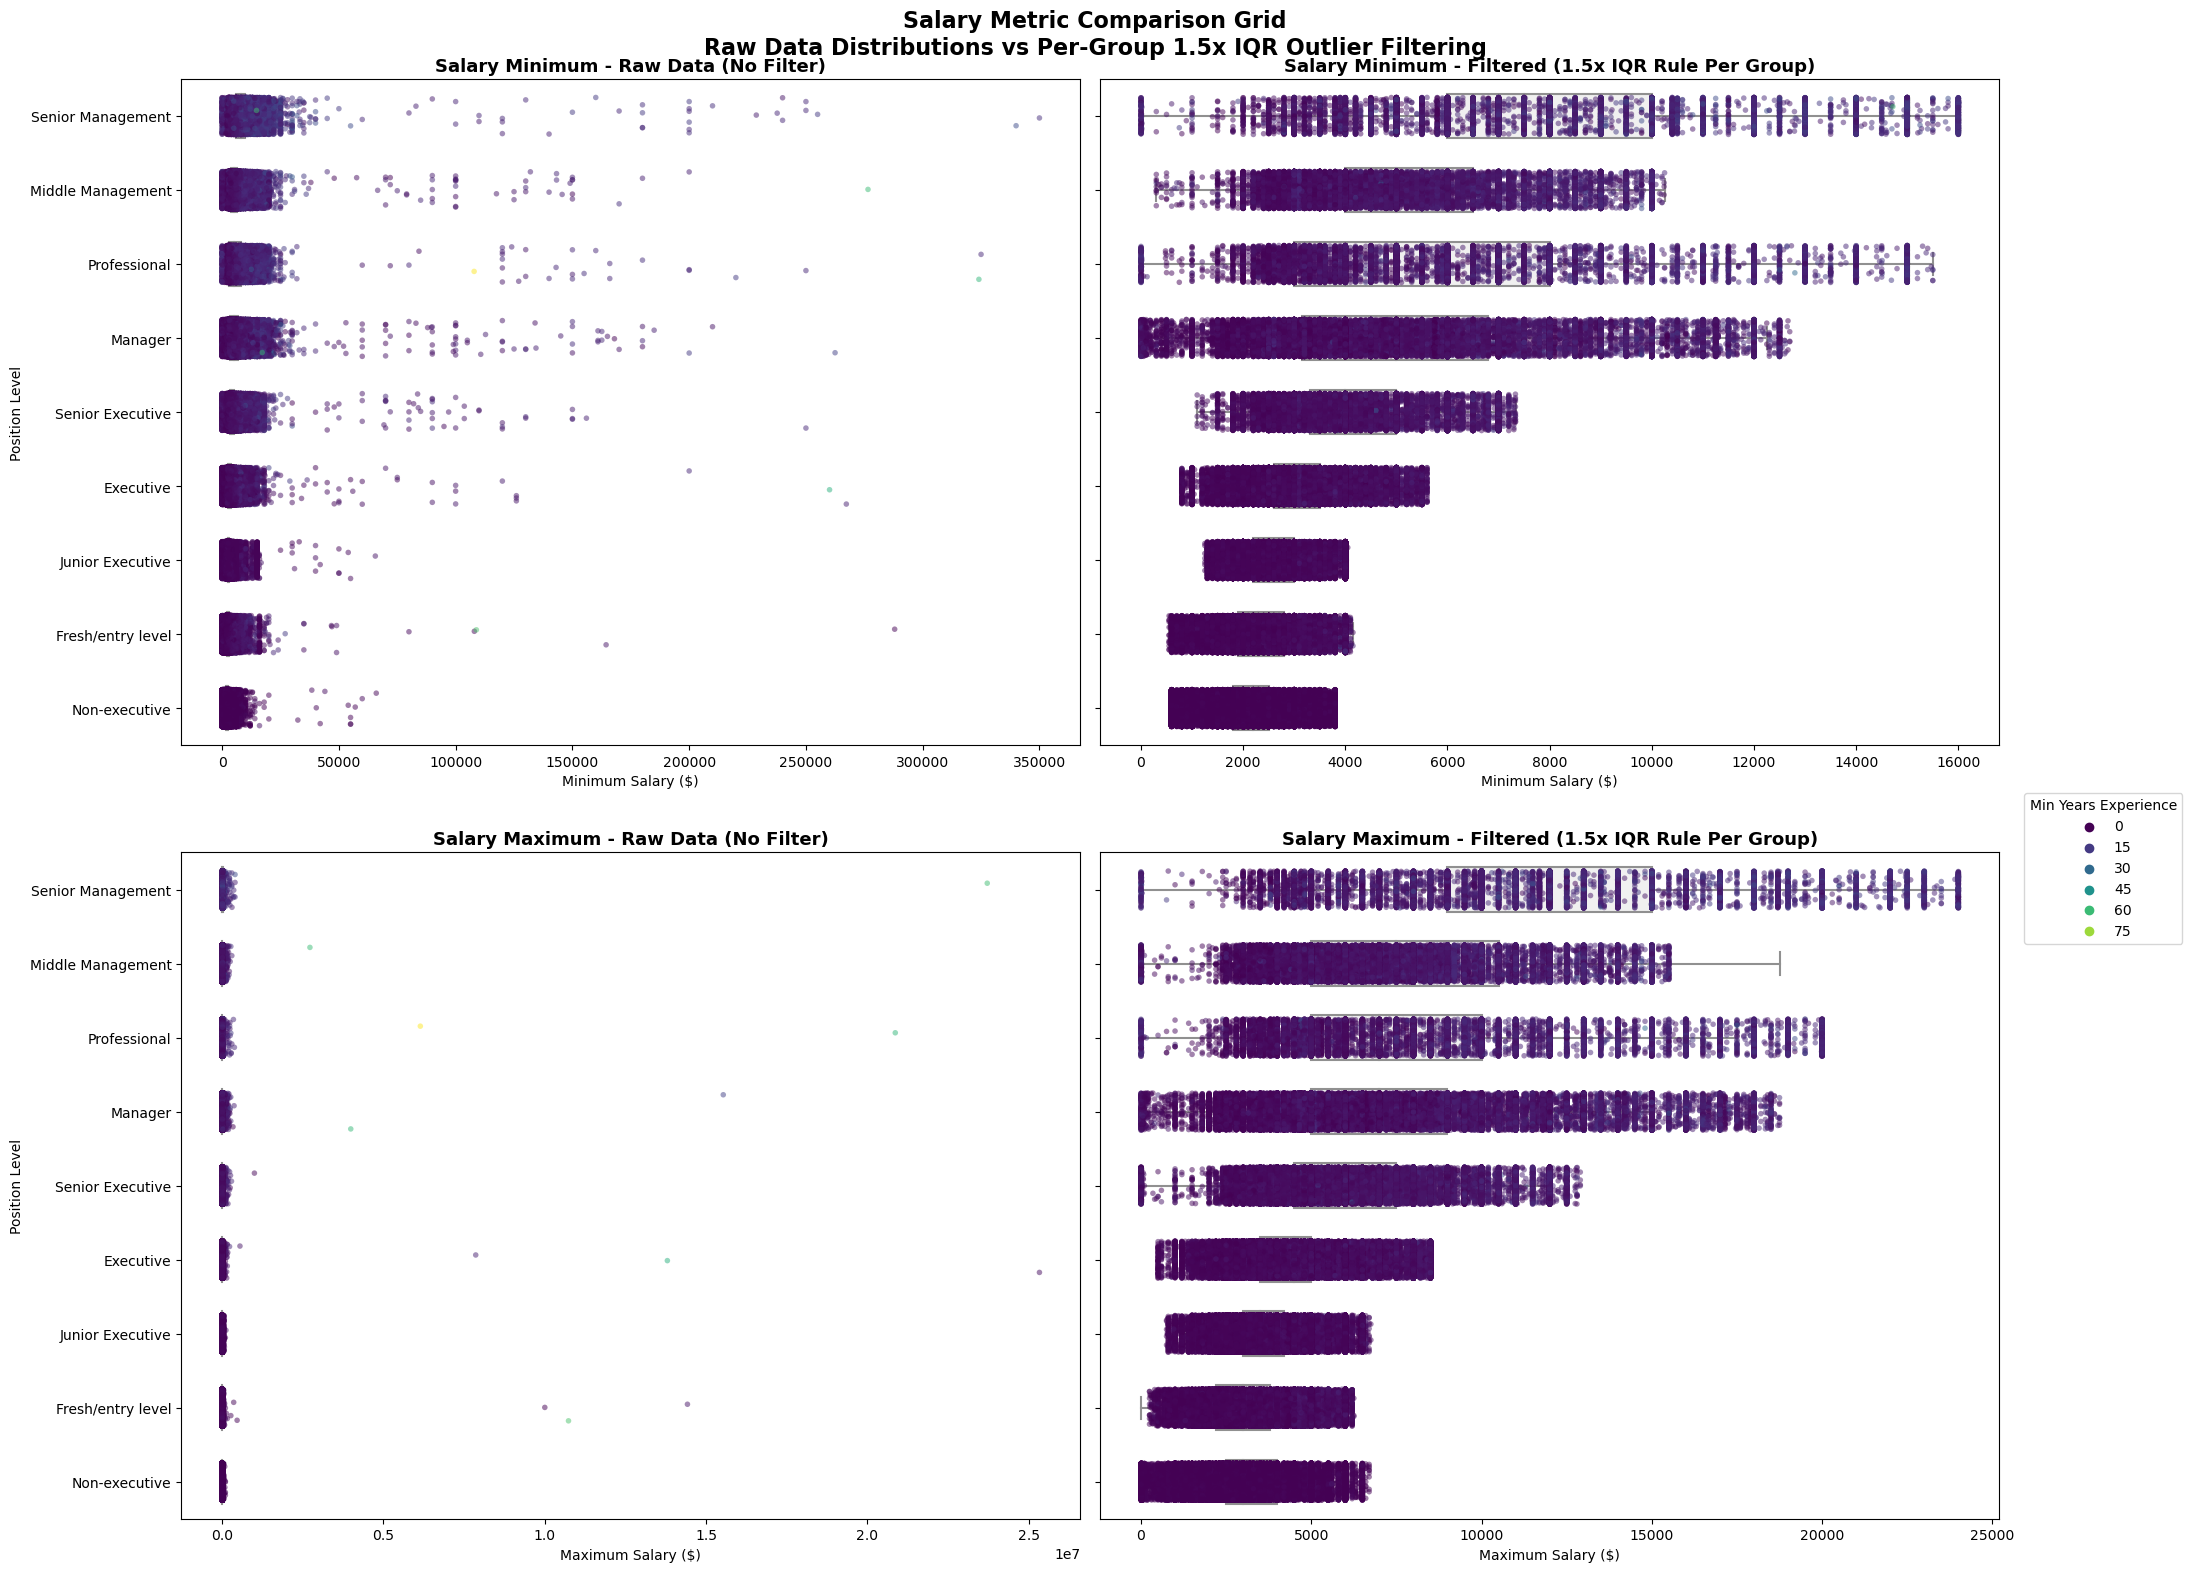

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 1. CALCULATE PER-GROUP IQR FENCES USING TRANSFORM
# ----------------------------------------------------------------------
# Salary Minimum IQR Calculations
min_q1 = df.groupby('positionLevels')['salary_minimum'].transform('quantile', 0.25)
min_q3 = df.groupby('positionLevels')['salary_minimum'].transform('quantile', 0.75)
min_iqr = min_q3 - min_q1
min_lower = min_q1 - 1.5 * min_iqr
min_upper = min_q3 + 1.5 * min_iqr

df_min_iqr = df[(df['salary_minimum'] >= min_lower) & (df['salary_minimum'] <= min_upper)]

# Salary Maximum IQR Calculations
max_q1 = df.groupby('positionLevels')['salary_maximum'].transform('quantile', 0.25)
max_q3 = df.groupby('positionLevels')['salary_maximum'].transform('quantile', 0.75)
max_iqr = max_q3 - max_q1
max_lower = max_q1 - 1.5 * max_iqr
max_upper = max_q3 + 1.5 * max_iqr

df_max_iqr = df[(df['salary_maximum'] >= max_lower) & (df['salary_maximum'] <= max_upper)]

# Standardize sorting orders by group medians
order_min = df.groupby('positionLevels')['salary_minimum'].median().sort_values(ascending=False).index
order_max = df.groupby('positionLevels')['salary_maximum'].median().sort_values(ascending=False).index

# ----------------------------------------------------------------------
# 2. INITIALIZE THE 2x2 SUBPLOT GRID
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(22, 16), sharey=True)

# ======================================================================
# ROW 1: SALARY MINIMUM
# ======================================================================
# [Row 0, Col 0] - Salary Minimum (Unfiltered)
sns.boxplot(data=df, x='salary_minimum', y='positionLevels', order=order_min, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[0, 0])
sns.stripplot(data=df, x='salary_minimum', y='positionLevels', order=order_min, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[0, 0])
axes[0, 0].set_title('Salary Minimum - Raw Data (No Filter)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Minimum Salary ($)')
axes[0, 0].set_ylabel('Position Level')
axes[0, 0].get_legend().remove()

# [Row 0, Col 1] - Salary Minimum (IQR Filtered per group)
sns.boxplot(data=df_min_iqr, x='salary_minimum', y='positionLevels', order=order_min, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[0, 1])
sns.stripplot(data=df_min_iqr, x='salary_minimum', y='positionLevels', order=order_min, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[0, 1])
axes[0, 1].set_title('Salary Minimum - Filtered (1.5x IQR Rule Per Group)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Minimum Salary ($)')
axes[0, 1].set_ylabel('')
axes[0, 1].get_legend().remove()

# ======================================================================
# ROW 2: SALARY MAXIMUM
# ======================================================================
# [Row 1, Col 0] - Salary Maximum (Unfiltered)
sns.boxplot(data=df, x='salary_maximum', y='positionLevels', order=order_max, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[1, 0])
sns.stripplot(data=df, x='salary_maximum', y='positionLevels', order=order_max, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[1, 0])
axes[1, 0].set_title('Salary Maximum - Raw Data (No Filter)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Maximum Salary ($)')
axes[1, 0].set_ylabel('Position Level')
axes[1, 0].get_legend().remove()

# [Row 1, Col 1] - Salary Maximum (IQR Filtered per group)
sns.boxplot(data=df_max_iqr, x='salary_maximum', y='positionLevels', order=order_max, color='#f0f0f0', showfliers=False, width=0.6, ax=axes[1, 1])
sns.stripplot(data=df_max_iqr, x='salary_maximum', y='positionLevels', order=order_max, hue='minimumYearsExperience', palette='viridis', alpha=0.5, jitter=0.25, size=4, ax=axes[1, 1])
axes[1, 1].set_title('Salary Maximum - Filtered (1.5x IQR Rule Per Group)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Maximum Salary ($)')
axes[1, 1].set_ylabel('')

# ----------------------------------------------------------------------
# 3. GLOBAL FINISHING TOUCHES
# ----------------------------------------------------------------------
# Place a single legend on the right side
axes[1, 1].legend(title='Min Years Experience', bbox_to_anchor=(1.02, 1.1), loc='upper left')

plt.suptitle('Salary Metric Comparison Grid\nRaw Data Distributions vs Per-Group 1.5x IQR Outlier Filtering', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


In [37]:
# save the cleaned DataFrame to a new CSV file
#df.to_csv('SGJobData_cleaned.csv', index=False)
df.to_csv('../db/SGJobData_cleaned.csv.gz', index=False, compression='gzip')